<a href="https://colab.research.google.com/github/MbuyiseloNtando/O.R-Tambo-International-Domestic-Passenger-Forecasting/blob/main/PassengerForecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Goal**

This project aims to forecast domestic monthly passenger traffic at O.R. Tambo International Airport using econometric, demographics as external indicators. The goal is to understand the drivers of passenger demand and build predictive models to improve forecasting accuracy for aviation planning and resource allocation.


In [64]:
#Importing manipulation and Visualion libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [65]:
# 1. Set the overall dark background (fixes text/axes colors)
plt.style.use('dark_background')

# 2. Define and apply  specific color palette
sns.set_palette(palette='Paired')

#Add a Seaborn style for better spacing/grid
sns.set_style("ticks")


In [66]:
#Install modules
!pip install pmdarima
!pip install skforecast

In [67]:
#importing our dataset
data = 'https://raw.githubusercontent.com/MbuyiseloNtando/O.R-Tambo-International-Domestic-Passenger-Forecasting/refs/heads/main/Cleaned%20and%20Transformed%20Data/Complete%20Dataset.csv'
df = pd.read_csv(data)
df.head(10)

,Date,Passengers,Consumer_spending.Consumer spending,CPI.CPI,Crude_oil.Crude Oil,GDP.GDP,Population.Population,Trade_balance.Trade balance (Rands),Unemployment_rate.Unemployment,Urbanisation.Urbanisation,population_growth.population_growth,tourists.tourists
0,2012/04/01,819885,2.793260e+12,6.1,890.44,4.344010e+11,53782567.0,-9900000000,24.84194,63.272,1.474794,802834.0
1,2012/05/01,765773,NaN,5.7,846.60,NaN,NaN,-8900000000,NaN,NaN,NaN,692046.0
2,2012/06/01,745731,NaN,5.5,761.13,NaN,NaN,-5700000000,NaN,NaN,NaN,653686.0
3,2012/07/01,794131,NaN,4.9,798.05,NaN,NaN,-6700000000,25.06654,NaN,NaN,793245.0
4,2012/07/01,794131,NaN,4.9,798.05,NaN,NaN,-5700000000,25.06654,NaN,NaN,793245.0
5,2012/08/01,791901,NaN,5.0,871.23,NaN,NaN,-12200000000,NaN,NaN,NaN,77562.0
6,2012/09/01,810003,NaN,5.5,879.46,NaN,NaN,-13800000000,NaN,NaN,NaN,765398.0
7,2012/10/01,858436,NaN,5.6,892.33,NaN,NaN,-21200000000,24.84194,NaN,NaN,784862.0
8,2012/11/01,798302,NaN,5.6,889.60,NaN,NaN,-7940000000,NaN,NaN,NaN,781096.0
9,2012/12/01,771312,NaN,5.7,874.73,NaN,NaN,9940000000,NaN,NaN,NaN,871774.0


## **Data Manipulation and Transformations**

In [68]:
df = df[['Date', 'Passengers', 'tourists.tourists', 'CPI.CPI', 'GDP.GDP', 'Population.Population',
         'Trade_balance.Trade balance (Rands)', 'Crude_oil.Crude Oil', 'Unemployment_rate.Unemployment']]
df.head(10)

,Date,Passengers,tourists.tourists,CPI.CPI,GDP.GDP,Population.Population,Trade_balance.Trade balance (Rands),Crude_oil.Crude Oil,Unemployment_rate.Unemployment
0,2012/04/01,819885,802834.0,6.1,4.344010e+11,53782567.0,-9900000000,890.44,24.84194
1,2012/05/01,765773,692046.0,5.7,NaN,NaN,-8900000000,846.60,NaN
2,2012/06/01,745731,653686.0,5.5,NaN,NaN,-5700000000,761.13,NaN
3,2012/07/01,794131,793245.0,4.9,NaN,NaN,-6700000000,798.05,25.06654
4,2012/07/01,794131,793245.0,4.9,NaN,NaN,-5700000000,798.05,25.06654
5,2012/08/01,791901,77562.0,5.0,NaN,NaN,-12200000000,871.23,NaN
6,2012/09/01,810003,765398.0,5.5,NaN,NaN,-13800000000,879.46,NaN
7,2012/10/01,858436,784862.0,5.6,NaN,NaN,-21200000000,892.33,24.84194
8,2012/11/01,798302,781096.0,5.6,NaN,NaN,-7940000000,889.60,NaN
9,2012/12/01,771312,871774.0,5.7,NaN,NaN,9940000000,874.73,NaN


In [69]:
#Remove a know duplicated rown
df.drop(df.index[4], inplace=True)
df=df[:-1]

In [70]:
df.duplicated().sum()

np.int64(0)

In [71]:
df[df.duplicated()]

,Date,Passengers,tourists.tourists,CPI.CPI,GDP.GDP,Population.Population,Trade_balance.Trade balance (Rands),Crude_oil.Crude Oil,Unemployment_rate.Unemployment


In [72]:
#Setting the date as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

In [73]:
#dding covi19 dummy
df['covid_flag'] = ((df.index >='2020-03-01') & (df.index < '2021-08-01')).astype(int)

In [74]:
df.columns

Index(['Passengers', 'tourists.tourists', 'CPI.CPI', 'GDP.GDP',
       'Population.Population', 'Trade_balance.Trade balance (Rands)',
       'Crude_oil.Crude Oil', 'Unemployment_rate.Unemployment', 'covid_flag'],
      dtype='object')

In [75]:
df.rename(columns ={'Crude_oil.Crude Oil' : 'crude_oil',
                  'tourists.tourists' : 'tourists',
                  'CPI.CPI' : 'cpi',
                  'GDP.GDP' : 'gdp',
                   'Population.Population' : 'population',
                   'Trade_balance.Trade balance (Rands)': 'Trade_balance',
                  'Unemployment_rate.Unemployment' : 'unemployment_rate'
                    },
          inplace=True)

In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 165 entries, 2012-04-01 to 2025-12-01
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Passengers         165 non-null    int64  
 1   tourists           161 non-null    float64
 2   cpi                164 non-null    float64
 3   gdp                14 non-null     float64
 4   population         14 non-null     float64
 5   Trade_balance      165 non-null    int64  
 6   crude_oil          165 non-null    float64
 7   unemployment_rate  55 non-null     float64
 8   covid_flag         165 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 12.9 KB


In [77]:
#interpolting gdp nd popultion columns
col = ['gdp', 'population']
df[col] = df[col].interpolate(method='linear')

In [78]:
#front filling tourists and cpi
df['tourists'] = df.tourists.ffill()
df['cpi'] = df.cpi.ffill()
df['unemployment_rate'] = df.unemployment_rate.ffill()

In [79]:
df['gdp_per_capta'] = df['gdp']/df['population']
df.drop(['population', 'gdp'], axis=1,
        inplace=True)

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 165 entries, 2012-04-01 to 2025-12-01
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Passengers         165 non-null    int64  
 1   tourists           165 non-null    float64
 2   cpi                165 non-null    float64
 3   Trade_balance      165 non-null    int64  
 4   crude_oil          165 non-null    float64
 5   unemployment_rate  165 non-null    float64
 6   covid_flag         165 non-null    int64  
 7   gdp_per_capta      165 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 11.6 KB


In [81]:
df.isna().sum()

,0
Passengers,0
tourists,0
cpi,0
Trade_balance,0
crude_oil,0
unemployment_rate,0
covid_flag,0
gdp_per_capta,0


In [82]:
df['month'] = df.index.month
df['year'] = df.index.year

In [83]:
df['covid_flag'].value_counts()

,count
covid_flag,
0,148
1,17


In [84]:
df.isna().sum()

,0
Passengers,0
tourists,0
cpi,0
Trade_balance,0
crude_oil,0
unemployment_rate,0
covid_flag,0
gdp_per_capta,0
month,0
year,0


## **EDA**

Text(0.5, 1.0, 'Monthly Passengers')

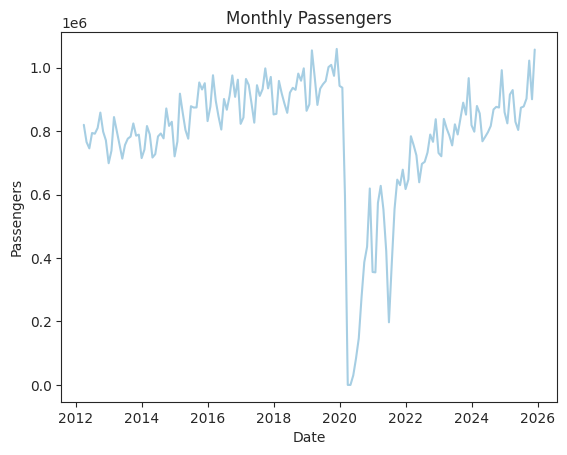

In [85]:
sns.lineplot(data=df, x=df.index, y='Passengers')
plt.title('Monthly Passengers')

In [86]:
num_cols = ['tourists', 'cpi', 'Trade_balance', 'crude_oil', 'unemployment_rate', 'gdp_per_capta']
cat_cols = ['month', 'year']

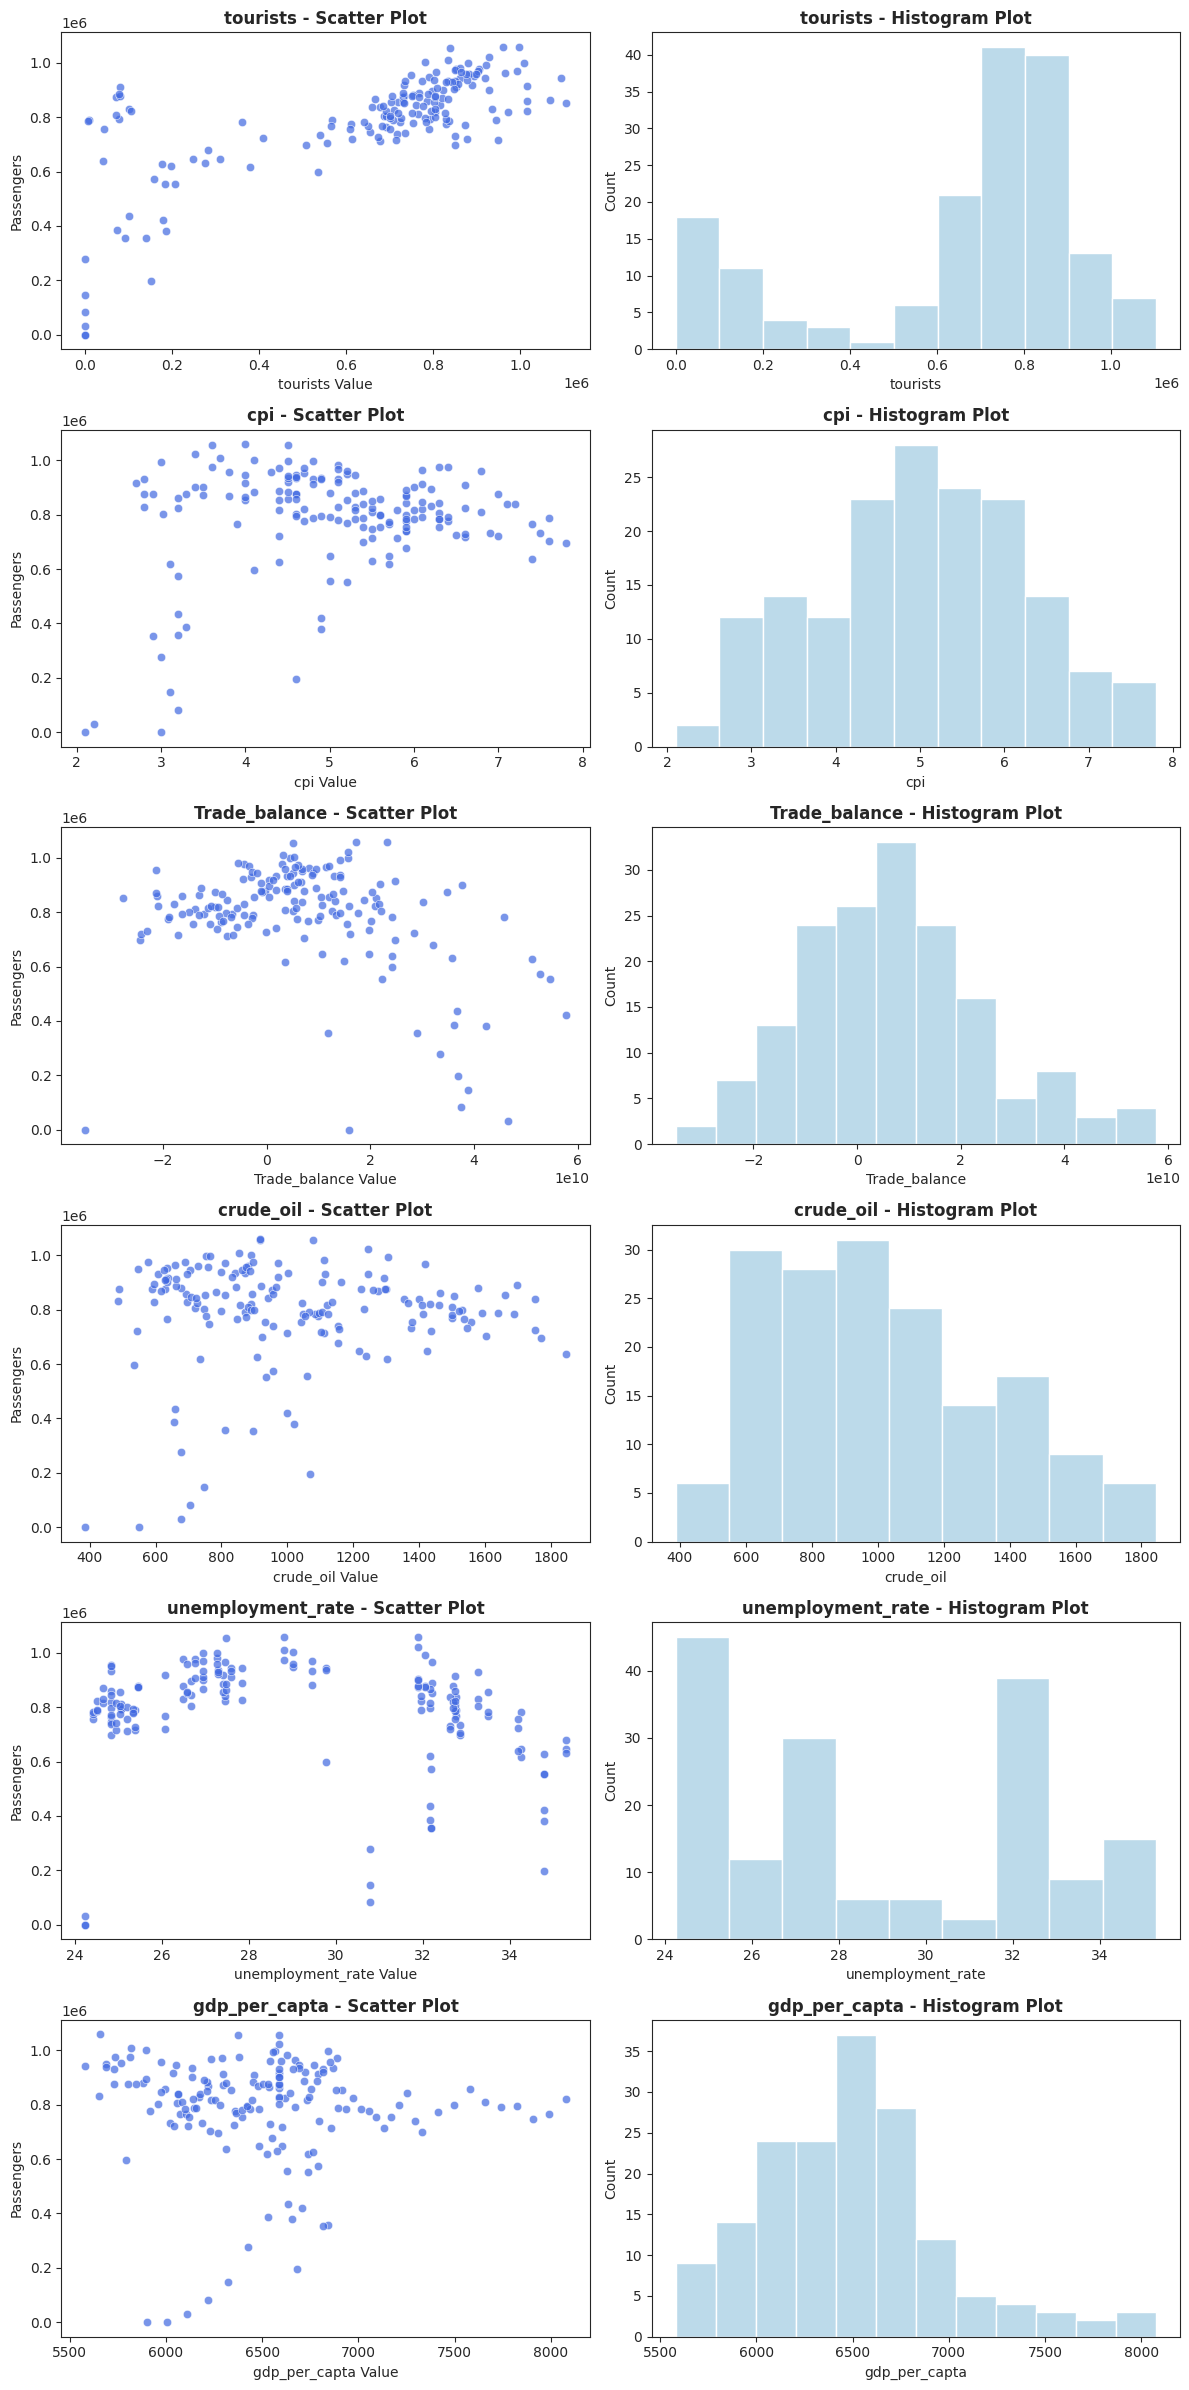

In [87]:
#Numerical column relationship and distribution
fig, axes = plt.subplots(
    nrows=len(num_cols),
    ncols=2,
    figsize=(12, 4 * len(num_cols)),
    squeeze=False
)

# 2. Iterate over each numerical column and plot distributions
for i, col in enumerate(num_cols):
    sns.scatterplot(y=df['Passengers'], x=df[col], ax=axes[i][0], color='royalblue', alpha=0.7)
    sns.histplot(df[col], ax=axes[i][1])

    # Left subplot styling
    axes[i][0].set_title(f'{col} - Scatter Plot', fontsize=12, fontweight='bold')
    axes[i][0].set_xlabel(f'{col} Value')
    axes[i][0].set_ylabel('Passengers')

    #Histogram styling
    axes[i][1].set_title(f'{col} - Histogram Plot', fontsize=12, fontweight='bold')
    axes[i][1].set_xlabel(f'{col}')


# 3. Prevent overlapping text labels
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Monthly Passengers')

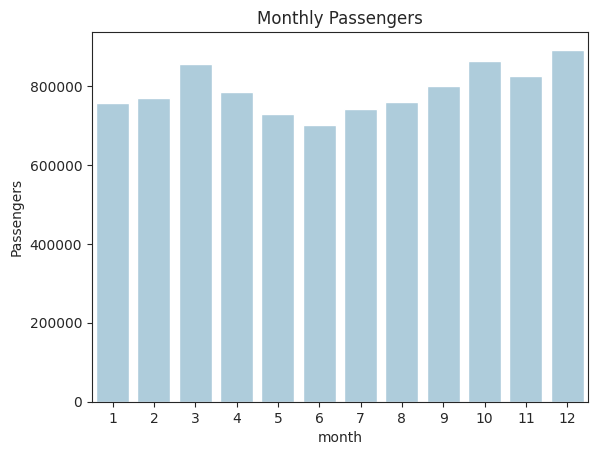

In [88]:
sns.barplot(df, x ='month', y='Passengers',
           errorbar=None)
plt.title('Monthly Passengers')

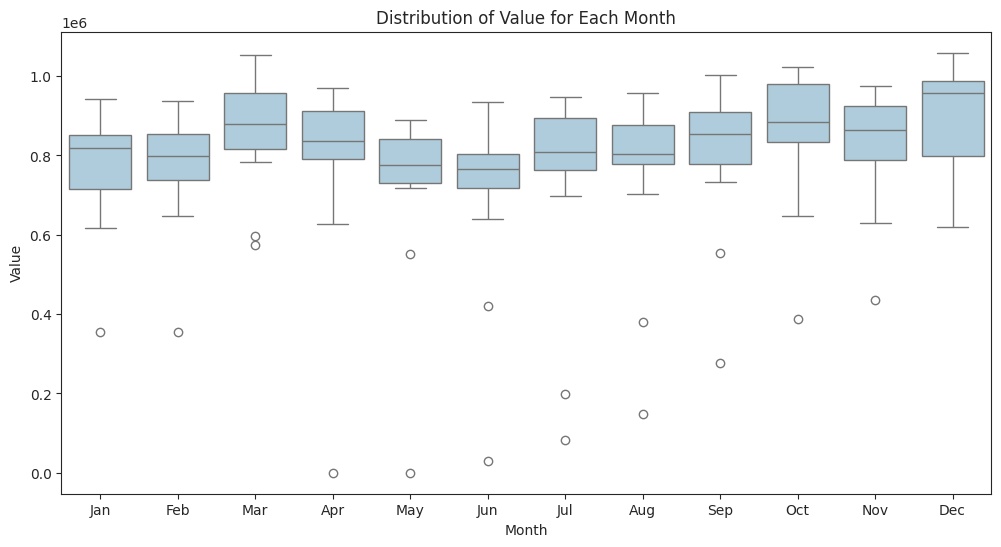

In [89]:
import calendar
df['month_name'] = df['month'].apply(lambda x: calendar.month_abbr[x])
month_order = [calendar.month_abbr[i] for i in range(1, 13)]

plt.figure(figsize=(12, 6))
sns.boxplot(x='month_name', y='Passengers', data=df,
            order=month_order)
plt.title('Distribution of Value for Each Month')
plt.xlabel('Month')
plt.ylabel('Value')
plt.show()


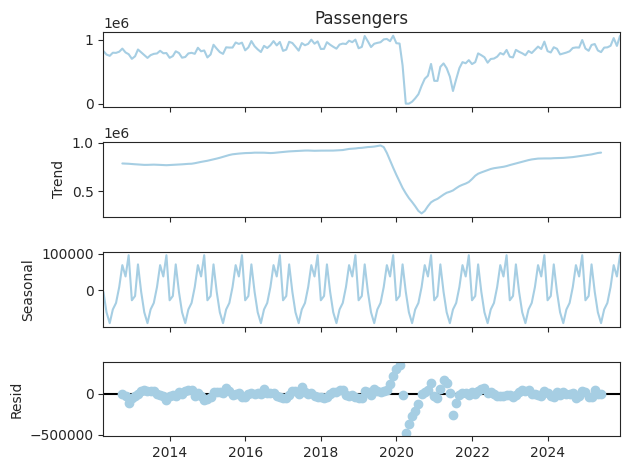

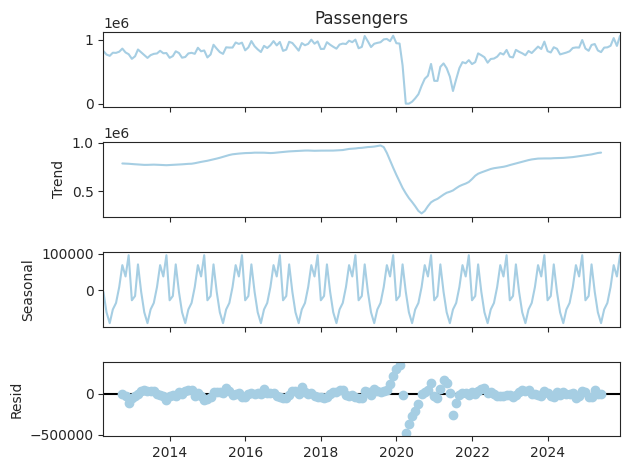

In [90]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Verifying seasonality (12 months)
season = seasonal_decompose(df['Passengers'],
                            model='additive', period=12)
season.plot()

## **BAISE NAIVE**

In [91]:
df_naive = df[['Passengers']]

In [92]:
naive_train = df_naive.iloc[ :133]
naive_test = df_naive.iloc[133: ]

In [93]:
naive_train['Passengers_t-1'] = naive_train['Passengers'].shift(1)

## Keeping row from 1 (since after shifting we have our first row as NULL)
naive_train = naive_train[['Passengers','Passengers_t-1']][1:]

In [94]:
from math import sqrt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error, mean_absolute_error

naive_rmse=sqrt(mean_squared_error(naive_train['Passengers_t-1'],naive_train['Passengers']))
nive_mape = mean_absolute_percentage_error(naive_train['Passengers_t-1'], naive_train['Passengers'])
print(r2_score(naive_train['Passengers_t-1'], naive_train['Passengers']))
print("RMSE:", naive_rmse)


y_true_arr = np.array(naive_train['Passengers']).flatten()
y_pred_arr = np.array(naive_train['Passengers_t-1']).flatten()

mask = y_true_arr != 0
y_true_filtered = y_true_arr[mask]
y_pred_filtered = y_pred_arr[mask]



# Re-calculate MAPE on the filtered data
clean_mape = mean_absolute_percentage_error(y_true_filtered, y_pred_filtered)
print(f"Filtered MAPE: {clean_mape:.4f}")

0.7856590315638807
RMSE: 98307.92372851034
Filtered MAPE: 0.1114


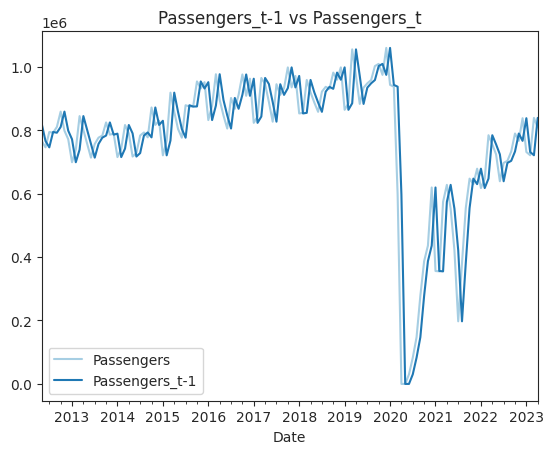

In [95]:
naive_train['Passengers'].plot(legend=True)
naive_train['Passengers_t-1'].plot(legend=True)

plt.title("Passengers_t-1 vs Passengers_t")
plt.show()

## **SARIMAX**

In [96]:
#importing SARIMA and ARIMA
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA

from pmdarima import auto_arima
from statsmodels.tsa.seasonal import seasonal_decompose

from sklearn.metrics import mean_squared_error, r2_score



In [97]:
df_sarima = df[['Passengers']]

#### **SARIMA**

In [98]:
X_sarima_train = df_sarima.iloc[ :133]
X_sarima_test = df_sarima.iloc[133: ]

In [99]:
from statsmodels.tsa.stattools import adfuller
test_result=adfuller(X_sarima_train['Passengers'])

In [100]:
#HYPOTHESIS TEST:
#Ho: It is non stationary
#H1: It is stationary

def adfuller_test(passenger):
    result=adfuller(passenger)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']

    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

Test stationarity for original series
-------------------------------------
ADF Test Statistic : -1.6880675938993281
p-value : 0.4372706603608704
#Lags Used : 13
Number of Observations Used : 119
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 
None

Test stationarity for differenced series (order=1)
--------------------------------------------------
ADF Test Statistic : -3.1599941332646084
p-value : 0.02242033463118228
#Lags Used : 13
Number of Observations Used : 118
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary
None

Test stationarity for differenced series (order=2)
--------------------------------------------------
ADF Test Statistic : -6.30663495044188
p-value : 3.311218539020681e-08
#Lags Used : 13
Number of Observations Used : 117
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary
None


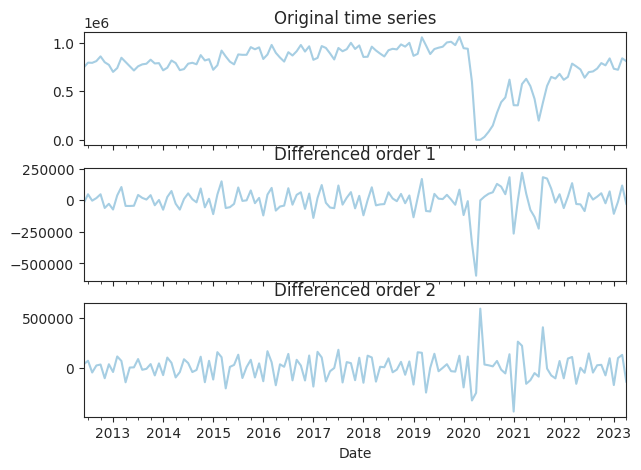

In [101]:
#differencing and stationary testing
X_sarima_train_diff1 = X_sarima_train['Passengers'].diff().dropna()
X_sarima_train_diff2 = X_sarima_train_diff1.diff().dropna()

with warnings.catch_warnings():
    warnings.filterwarnings('ignore')
    print('Test stationarity for original series')
    print('-------------------------------------')
    print(adfuller_test(X_sarima_train['Passengers']))

    print('\nTest stationarity for differenced series (order=1)')
    print('--------------------------------------------------')
    print(adfuller_test(X_sarima_train_diff1))

    print('\nTest stationarity for differenced series (order=2)')
    print('--------------------------------------------------')
    print(adfuller_test(X_sarima_train_diff2))

# Plot series
# ==============================================================================
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(7, 5), sharex=True)
X_sarima_train['Passengers'].plot(ax=axs[0], title='Original time series')
X_sarima_train_diff1.plot(ax=axs[1], title='Differenced order 1')
X_sarima_train_diff2.plot(ax=axs[2], title='Differenced order 2');

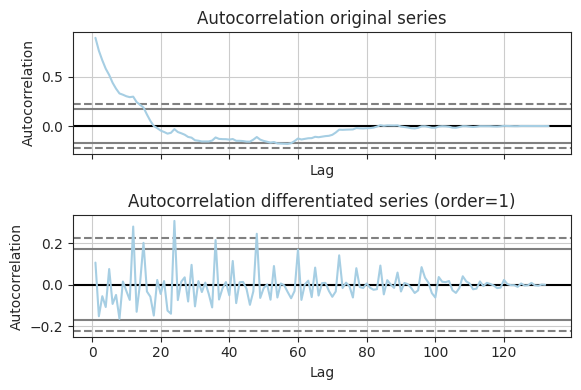

In [102]:
#autocorrelation_plot
# Autocorrelation plot for original and differentiated series
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(6, 4), sharex=True)
autocorrelation_plot(X_sarima_train['Passengers'], ax=axs[0])
axs[0].set_title('Autocorrelation original series')

# Autocorrelation plot for original and differentiated series
autocorrelation_plot(X_sarima_train_diff1, ax=axs[1])
axs[1].set_title('Autocorrelation differentiated series (order=1)');

plt.tight_layout()

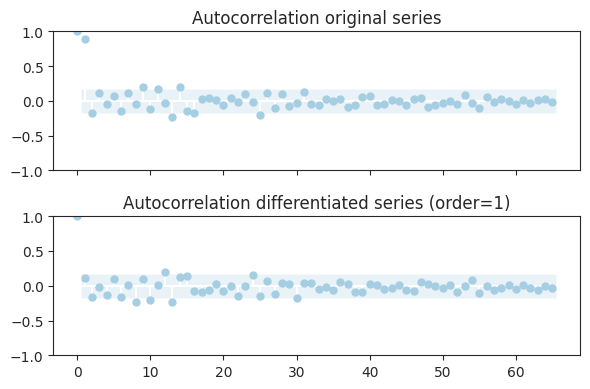

In [103]:
# Autocorrelation plot for original and differentiated series
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(6, 4), sharex=True)
plot_pacf(X_sarima_train['Passengers'], ax=axs[0], method='ywm',lags=65)
axs[0].set_title('Autocorrelation original series')
plot_pacf(X_sarima_train_diff1, ax=axs[1], method='ywm', lags=65)
axs[1].set_title('Autocorrelation differentiated series (order=1)');

plt.tight_layout()

In [104]:
X_sarima_train_diff1.drop_duplicates(inplace=True)
X_sarima_train_diff1.duplicated().sum()

np.int64(0)

In [105]:
X_sarima_train_diff1.head(10)

,Passengers
Date,
2012-05-01,-54112.0
2012-06-01,-20042.0
2012-07-01,48400.0
2012-08-01,-2230.0
2012-09-01,18102.0
2012-10-01,48433.0
2012-11-01,-60134.0
2012-12-01,-26990.0
2013-01-01,-72497.0


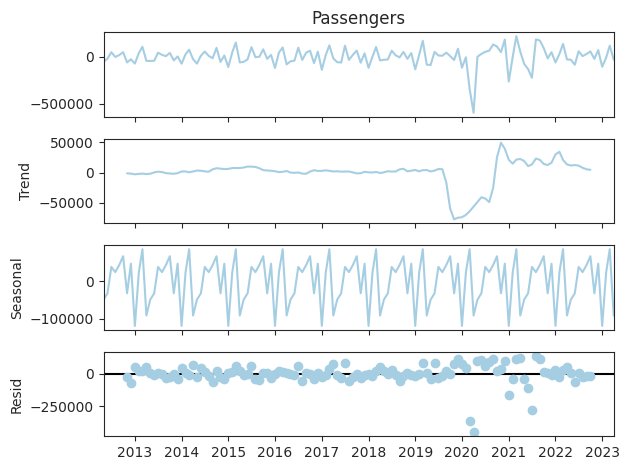

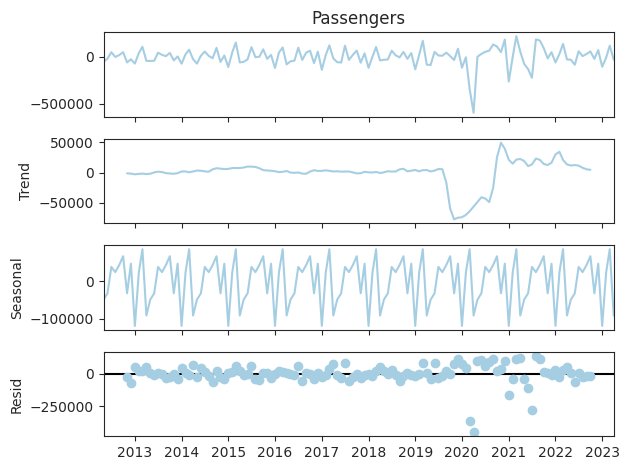

In [106]:
# Verifying seasonality (12 months)
X_sarima_train_diff1.drop_duplicates(inplace=True)

season = seasonal_decompose(X_sarima_train_diff1.asfreq("MS"), model='additive')
season.plot(season)

In [107]:
# First-order differentiation combined with seasonal differentiation
data_diff_1_12 = X_sarima_train.diff().diff(12).dropna()

warnings.filterwarnings("ignore")
adfuller_result = adfuller(data_diff_1_12)
print(f'ADF Statistic: {adfuller_result[0]}, p-value: {adfuller_result[1]}')

ADF Statistic: -4.036507663314208, p-value: 0.0012309599067719295


In [108]:
sarimax = SARIMAX(df_sarima['Passengers'], order =(1,1,1),
                  seasonal_order=(1,1,1,12))
jnb_result = sarimax.fit()

start = len(X_sarima_train)
end = len(X_sarima_train) + len(X_sarima_test)-1
predict_sarima1 = jnb_result.predict(start, end).rename('prediction')

In [109]:
predict_sarima1.shape, X_sarima_test.shape

((32,), (32, 1))

In [110]:
# Ensuring the index of both is datetime
X_sarima_test.index = pd.to_datetime(X_sarima_test.index)
predict_sarima1.index = pd.to_datetime(predict_sarima1.index)

# Sorting the indexes
X_sarima_test = X_sarima_test.sort_index()
predict_sarima1 = predict_sarima1.sort_index()

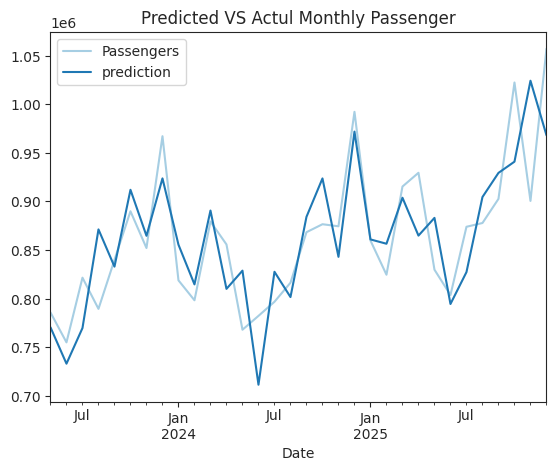

In [111]:
#plotting actuals vs predicted Passengers
X_sarima_test['Passengers'].plot(legend=True)
predict_sarima1.plot(legend=True)

plt.title("Predicted VS Actul Monthly Passenger");

In [112]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score, mean_absolute_error
from math import sqrt

#Evaluating the model
sarima_rmse = sqrt(mean_squared_error(X_sarima_test.Passengers, np.array(predict_sarima1)))
sarima_mape = mean_absolute_percentage_error(X_sarima_test.Passengers,np.array(predict_sarima1))
sarima_mae = mean_absolute_error(X_sarima_test.Passengers, np.array(predict_sarima1))
sarima_r2_score = r2_score(X_sarima_test.Passengers,  np.array(predict_sarima1))


In [113]:
metrics = {
    'RMSE': sarima_rmse,
    'MAPE': sarima_mape,
    'MAE' : sarima_mae,
    'sarima_r2_score': sarima_r2_score
}

# Display as table
df_metrics = pd.DataFrame([metrics])
df_metrics

,RMSE,MAPE,MAE,sarima_r2_score
0,47427.03676,0.04397,38247.899249,0.556415


In [114]:
future_dates_jnb = pd.date_range(start=df.index[-1], periods=25, freq='M')[1:]
jnb_forecast = pd.Series(jnb_result.forecast(steps=24).values, index=future_dates_jnb).to_frame(name='forecast')


<Figure size 1200x700 with 0 Axes>

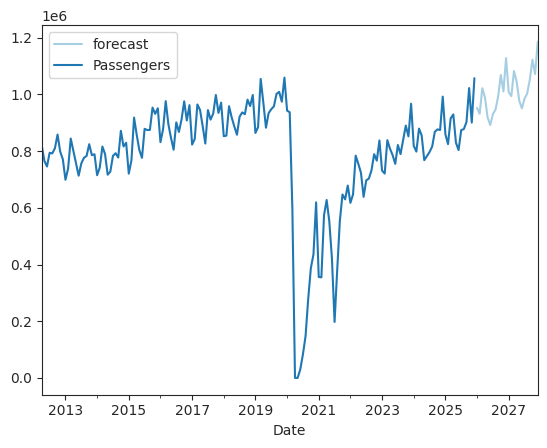

In [115]:
fig = plt.figure(figsize=(12,7))
jnb_forecast.plot()
df['Passengers'].plot(legend=True)
plt.show()

#### **SARIMAX**

In [116]:
df_exog = df[['cpi', 'gdp_per_capta', 'tourists', 'Passengers', 'covid_flag']]

In [117]:
X_exog_train = df_exog.iloc[ :133]
X_exog_test = df_exog.iloc[133: ]

In [118]:
mod = SARIMAX((X_exog_train['Passengers']),
              exog=X_exog_train[['cpi', 'tourists', 'covid_flag', 'gdp_per_capta']],
             order=(1,1,1), seasonal_order=(1,1,1,12))
result_exog= mod.fit()

prediction_exog = result_exog.predict(
    start = len(X_exog_train),
    end = len(X_exog_train) + len(X_exog_test)-1,
    exog=X_exog_test[['cpi', 'tourists', 'covid_flag', 'gdp_per_capta']]).rename('Prediction')



In [119]:
# Ensuring the index of both is datetime
X_exog_train.index = pd.to_datetime(X_exog_train.index)
prediction_exog.index = pd.to_datetime(prediction_exog.index)

# Sorting the indexes
test_post_exog = X_exog_train.sort_index()
prediction_exog = prediction_exog.sort_index()

In [120]:
test_post_exog.shape, prediction_exog.shape

((133, 5), (32,))

<Axes: xlabel='Date'>

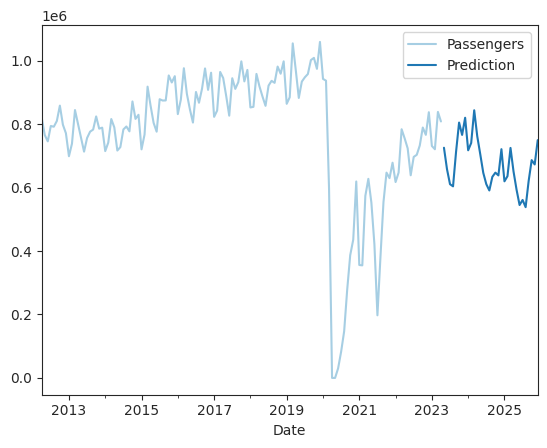

In [121]:
X_exog_train['Passengers'].plot(legend=True)
prediction_exog.plot(legend=True)

In [122]:
#Evaluating the SARIMA model
from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score,mean_absolute_percentage_error,mean_absolute_error


rmse_exog = sqrt(mean_squared_error(X_exog_test['Passengers'], np.array(prediction_exog)))
mpe_exog = mean_absolute_percentage_error(np.array(prediction_exog), X_exog_test['Passengers'])
r2_score_exog = r2_score(np.array(prediction_exog), X_exog_test['Passengers'])
mae_exog = mean_absolute_error(X_exog_test['Passengers'], np.array(prediction_exog))

In [123]:
metrics = {
    'RMSE': rmse_exog,
    'MAPE': mpe_exog,
    'MAE' : mae_exog,
    'R2_Score': r2_score_exog }

# Displaying as table
df_metrics = pd.DataFrame([metrics])
df_metrics

,RMSE,MAPE,MAE,R2_Score
0,208722.036607,0.294517,189544.41928,-6.250898


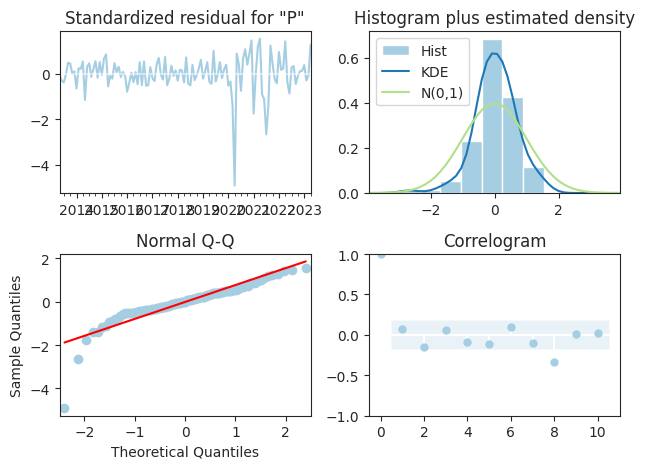

In [124]:
 result_exog.plot_diagnostics()
plt.tight_layout()

## **XGBOOST**

In [125]:
df_xg = df.copy()
df_xg.head()

,Passengers,tourists,cpi,Trade_balance,crude_oil,unemployment_rate,covid_flag,gdp_per_capta,month,year,month_name
Date,,,,,,,,,,,
2012-04-01,819885,802834.0,6.1,-9900000000,890.44,24.84194,0,8076.985243,4,2012,Apr
2012-05-01,765773,692046.0,5.7,-8900000000,846.60,24.84194,0,7992.946301,5,2012,May
2012-06-01,745731,653686.0,5.5,-5700000000,761.13,24.84194,0,7909.217413,6,2012,Jun
2012-07-01,794131,793245.0,4.9,-6700000000,798.05,25.06654,0,7825.796867,7,2012,Jul
2012-08-01,791901,77562.0,5.0,-12200000000,871.23,25.06654,0,7742.682963,8,2012,Aug


In [126]:
df_xg1 = df_xg.copy()
df_xg1=df_xg1.asfreq('MS')

In [127]:
#train and test sets
df_train_xg1 = df_xg1[:132]
df_test_xg1 = df_xg1[132:]

In [128]:
from skforecast.preprocessing import RollingFeatures
window_features = RollingFeatures(
    stats=["mean", "std", "max"],
    window_sizes=[24, 24, 24]
)

In [129]:
from xgboost import XGBRegressor
from skforecast.recursive import ForecasterRecursive

forecaster = ForecasterRecursive(
                estimator       = XGBRegressor(enable_categorical=True),
                lags            = 25,
                window_features = window_features

             )

# Train forecaster
# ==============================================================================
forecaster.fit(y=df_train_xg1['Passengers'])
forecaster



=================== 
ForecasterRecursive 
=================== 
Estimator: XGBRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25] 
Window features: ['roll_mean_24', 'roll_std_24', 'roll_max_24'] 
Window size: 25 
Series name: Passengers 
Exogenous included: False 
Exogenous names: None 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2012-04-01 00:00:00'), Timestamp('2023-03-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <MonthBegin> 
Estimator parameters: 
    {'objective': 'reg:squarederror', 'base_score': None, 'booster': None,
    'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None,
    'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None,
    'enable_categorical': False, 'eval_metric': None, 'feature_types': None,
    'feature_weights': None, 'gamma': None, 'grow_policy': None,
    'importance_type': None, 'interaction_constraints': None, 'learning_rate':
    None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None,
    'max_delta_step': None, 'max_depth': None, 'max_leaves': None,
    'min_child_weight': None, 'missing': nan, 'monotone_constraints': None,
    'multi_strategy': None, 'n_estimators': None, 'n_jobs': None,
    'num_parallel_tree': None, 'random_state': None, 'reg_alpha': None,
    'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None,
    'subsample': None, 'tree_method': None, 'validate_parameters': None,
    'verbosity': None} 
fit_kwargs: {} 
Creation date: 2026-06-25 14:55:34 
Last fit date: 2026-06-25 14:55:35 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

In [130]:
pred = forecaster.predict(steps=33)


<Axes: xlabel='Date'>

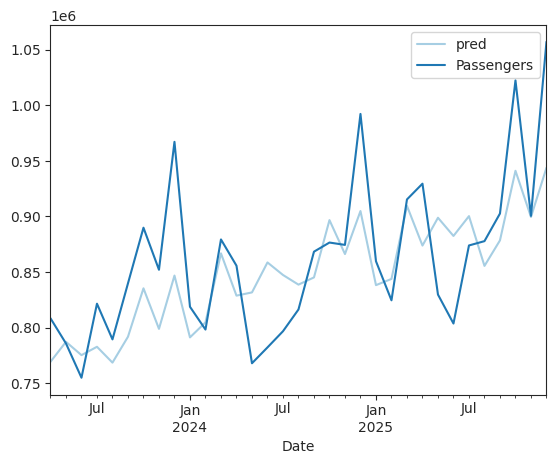

In [131]:
pred.plot(legend=True)
df_test_xg1['Passengers'].plot(legend=True)

In [132]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
mean_absolute_error(y_true=df_test_xg1['Passengers'],
                   y_pred=pred)

40620.895833333336

In [133]:
#Back seating
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import backtesting_forecaster

cv = TimeSeriesFold(
        steps              = 12,
        initial_train_size = 120,
        refit              = True,
)

def weighted_absolute_percentage_error(y_true, y_pred):
    """
    Custom WAPE metric for data with zeros.
    """
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

metric, predictions = backtesting_forecaster(
    forecaster = forecaster,
    y          = df_train_xg1['Passengers'],
    cv         = cv,
    metric     = ['mean_squared_error', weighted_absolute_percentage_error, 'mean_absolute_error']
)

metric

  0%|          | 0/1 [00:00<?, ?it/s]

,mean_squared_error,weighted_absolute_percentage_error,mean_absolute_error
0,4.182510e+09,0.078137,58175.098958


<Axes: xlabel='Date'>

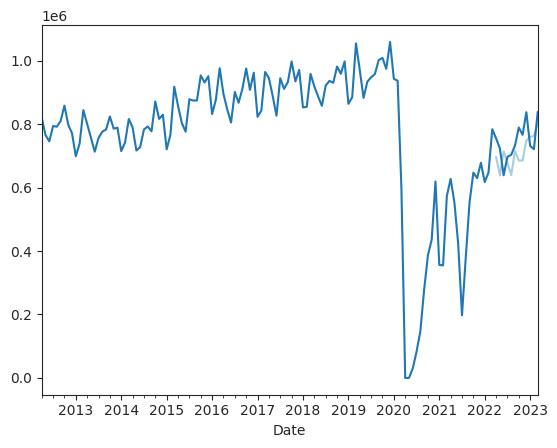

In [134]:
predictions['pred'].plot()
df_train_xg1['Passengers'].plot()

#### **Exogeneous Variables**

In [135]:
import holidays

daily_rng = pd.date_range(start='2012-04-01', end='2025-12-01', freq='D')
us_holidays = holidays.ZA()

# 2. Map holidays to the daily range
df_daily = pd.DataFrame(index=daily_rng)
df_daily['is_holiday'] = df_daily.index.map(lambda x: 1 if x in us_holidays else 0)

# 3. Resample to Month Start ("MS") frequency
# Summing gives "Holiday Count" per month
df_monthly_holidays = df_daily['is_holiday'].resample('MS').sum().to_frame()
df_monthly_holidays['Month'] = df.index.month
df_monthly_holidays['Year'] = df.index.year

#Covid19 dummy
target_dates = df_monthly_holidays.index[(df_monthly_holidays.index >='2020-03-01') & (df_monthly_holidays.index < '2021-08-01')]
target_dates2 = df_monthly_holidays.index[(df_monthly_holidays.index >='2013-03-01') & (df_monthly_holidays.index < '2014-02-01')]

# Create the dummy column
df_monthly_holidays['covid_binary'] = df_monthly_holidays.index.isin(target_dates).astype(int)
df_monthly_holidays['bankrupsy_binary'] = df_monthly_holidays.index.isin(target_dates2).astype(int)

df_monthly_holidays.head()

,is_holiday,Month,Year,covid_binary,bankrupsy_binary
2012-04-01,3,4,2012,0,0
2012-05-01,1,5,2012,0,0
2012-06-01,1,6,2012,0,0
2012-07-01,0,7,2012,0,0
2012-08-01,1,8,2012,0,0


In [136]:
df_monthly_holidays['covid_binary'].value_counts()

,count
covid_binary,
0,148
1,17


In [137]:
df_monthly_holidays['bankrupsy_binary'].value_counts()

,count
bankrupsy_binary,
0,154
1,11


In [138]:
merged_df = pd.merge(df_xg1, df_monthly_holidays, left_index=True, right_index=True, how='inner')
merged_df=merged_df.asfreq('MS')

In [139]:
from sklearn.preprocessing import FunctionTransformer

# Cyclical encoding with sine/cosine transformation
def sin_transformer(period):
	return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))

def cos_transformer(period):
	return FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))

data_encoded_sin_cos = merged_df.copy()
data_encoded_sin_cos["month_sin"] = sin_transformer(12).fit_transform(merged_df['Month'])
data_encoded_sin_cos["month_cos"] = cos_transformer(12).fit_transform(merged_df['Month'])
data_encoded_sin_cos.head()

,Passengers,tourists,cpi,Trade_balance,crude_oil,unemployment_rate,covid_flag,gdp_per_capta,month,year,month_name,is_holiday,Month,Year,covid_binary,bankrupsy_binary,month_sin,month_cos
Date,,,,,,,,,,,,,,,,,,
2012-04-01,819885,802834.0,6.1,-9900000000,890.44,24.84194,0,8076.985243,4,2012,Apr,3,4,2012,0,0,8.660254e-01,-0.500000
2012-05-01,765773,692046.0,5.7,-8900000000,846.60,24.84194,0,7992.946301,5,2012,May,1,5,2012,0,0,5.000000e-01,-0.866025
2012-06-01,745731,653686.0,5.5,-5700000000,761.13,24.84194,0,7909.217413,6,2012,Jun,1,6,2012,0,0,1.224647e-16,-1.000000
2012-07-01,794131,793245.0,4.9,-6700000000,798.05,25.06654,0,7825.796867,7,2012,Jul,0,7,2012,0,0,-5.000000e-01,-0.866025
2012-08-01,791901,77562.0,5.0,-12200000000,871.23,25.06654,0,7742.682963,8,2012,Aug,1,8,2012,0,0,-8.660254e-01,-0.500000


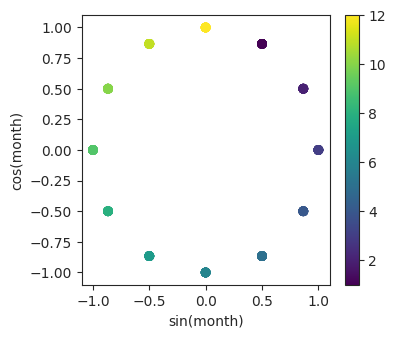

In [140]:
fig, ax = plt.subplots(figsize=(4., 3.5))
sp = ax.scatter(
        data_encoded_sin_cos["month_sin"],
        data_encoded_sin_cos["month_cos"],
        c=data_encoded_sin_cos["Month"],
        cmap='viridis'
     )
ax.set(
    xlabel="sin(month)",
    ylabel="cos(month)",
)
_ = fig.colorbar(sp)
data_encoded_sin_cos = data_encoded_sin_cos.drop(columns='Month')

In [141]:
# Assuming 'df' has a DatetimeIndex with 'MS' frequency
#data_encoded_sin_cos['oil_roll_mean_3M'] = data_encoded_sin_cos['crude_oil'].rolling(window=3).mean()
#data_encoded_sin_cos['oil_roll_mean_1Y'] = data_encoded_sin_cos['crude_oil'].rolling(window=12).mean()
data_encoded_sin_cos['tourists_roll_mean_3M'] = data_encoded_sin_cos['tourists'].rolling(window=3).mean()
data_encoded_sin_cos['tourists_roll_mean_1Y'] = data_encoded_sin_cos['tourists'].rolling(window=12).mean()

In [142]:
data_encoded_sin_cos.drop('month_name', axis=1, inplace=True)

In [143]:
#train and test sets
df_train_xg2 = data_encoded_sin_cos[:132]
df_test_xg2 = data_encoded_sin_cos[132:]

In [144]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Fits to data and transforms it in one step
scaled_data = scaler.fit_transform(df_train_xg2)

In [145]:
df_train_xg2.columns

Index(['Passengers', 'tourists', 'cpi', 'Trade_balance', 'crude_oil',
       'unemployment_rate', 'covid_flag', 'gdp_per_capta', 'month', 'year',
       'is_holiday', 'Year', 'covid_binary', 'bankrupsy_binary', 'month_sin',
       'month_cos', 'tourists_roll_mean_3M', 'tourists_roll_mean_1Y'],
      dtype='object')

In [146]:
exog_features = ['bankrupsy_binary','is_holiday', 'covid_binary',
                 'month_sin', 'month_cos', 'tourists_roll_mean_3M','tourists_roll_mean_1Y' ]

In [147]:
from xgboost import XGBRegressor
from skforecast.model_selection import backtesting_forecaster

def weighted_absolute_percentage_error(y_true, y_pred):
    """
    Custom WAPE metric for data with zeros.
    """
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

metric, predictions = backtesting_forecaster(
                forecaster= forecaster,
                y = df_train_xg2['Passengers'],
                exog = data_encoded_sin_cos[exog_features],
                cv = cv,
                metric = [weighted_absolute_percentage_error, 'mean_absolute_error']
             )



  0%|          | 0/1 [00:00<?, ?it/s]

In [148]:
metric

,weighted_absolute_percentage_error,mean_absolute_error
0,0.067861,50524.598958


<Axes: xlabel='Date'>

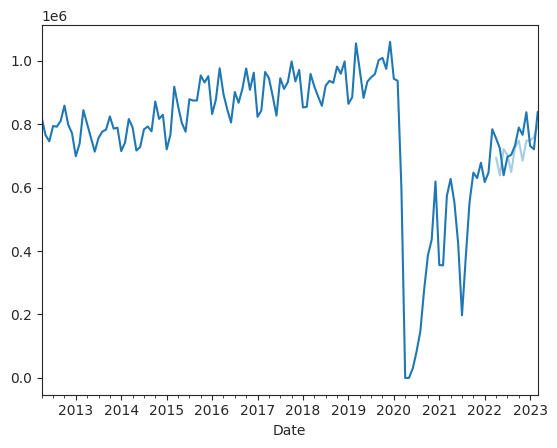

In [149]:
predictions['pred'].plot()
df_train_xg2['Passengers'].plot()

<Axes: xlabel='Date'>

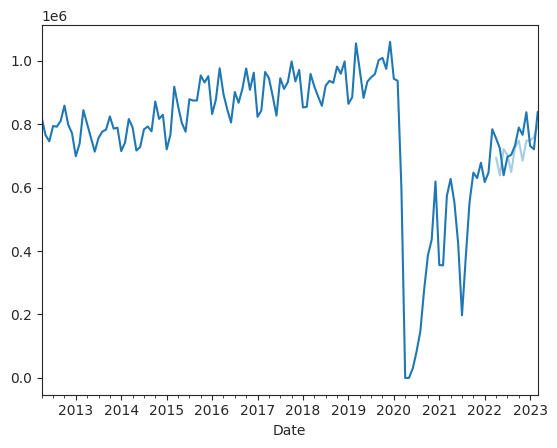

In [150]:
predictions['pred'].plot()
df_train_xg2['Passengers'].plot()

In [151]:
# Hyperparameters search
from skforecast.model_selection import bayesian_search_forecaster

# Lags grid
lags_grid = [48, 72, [1, 2, 3, 23, 24, 25]]

# Estimator hyperparameters search space
def search_space(trial):
    search_space  = {
        'n_estimators'    : trial.suggest_int('n_estimators', 400, 1200, step=100),
        'max_depth'       : trial.suggest_int('max_depth', 3, 10, step=1),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 1),
        'subsample'       : trial.suggest_float('subsample', 0.1, 1),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.1, 1),
        'gamma'           : trial.suggest_float('gamma', 0, 1),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0, 1),
        'lags'            : trial.suggest_categorical('lags', lags_grid)
    }
    return search_space

# Folds
cv_searh = TimeSeriesFold(
                steps              = 12,
                initial_train_size = 120,
                refit              = True,
            )
def weighted_absolute_percentage_error(y_true, y_pred):
    """
    Custom WAPE metric for data with zeros.
    """
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))

results_search, frozen_trial = bayesian_search_forecaster(
                                    forecaster= forecaster,
                                    y = df_train_xg2['Passengers'],
                                    exog = df_train_xg2[exog_features],
                                    search_space = search_space,
                                    cv           = cv_searh,
                                    metric       = ['mean_absolute_error', weighted_absolute_percentage_error],
                                    n_trials     = 20
                                )
best_params = results_search['params'].iat[0]
best_lags = results_search['lags'].iat[0]


  0%|          | 0/20 [00:00<?, ?it/s]

In [152]:
forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: XGBRegressor 
Lags: [ 1  2  3 23 24 25] 
Window features: ['roll_mean_24', 'roll_std_24', 'roll_max_24'] 
Window size: 25 
Series name: Passengers 
Exogenous included: True 
Exogenous names: 
    bankrupsy_binary, is_holiday, covid_binary, month_sin, month_cos,
    tourists_roll_mean_3M, tourists_roll_mean_1Y 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2012-04-01 00:00:00'), Timestamp('2023-03-01 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <MonthBegin> 
Estimator parameters: 
    {'objective': 'reg:squarederror', 'base_score': None, 'booster': None,
    'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None,
    'colsample_bytree': 0.9040502468054213, 'device': 'cpu',
    'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric':
    None, 'feature_types': None, 'feature_weights': None, 'gamma':
    0.9441600182038796, 'grow_policy': None, 'importance_type': None,
    'interaction_constraints': None, 'learning_rate': 0.31913861074274064,
    'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None,
    'max_delta_step': None, 'max_depth': 6, 'max_leaves': None,
    'min_child_weight': None, 'missing': nan, 'monotone_constraints': None,
    'multi_strategy': None, 'n_estimators': 800, 'n_jobs': None,
    'num_parallel_tree': None, 'random_state': None, 'reg_alpha':
    0.5018366758843366, 'reg_lambda': 0.6239529517921112, 'sampling_method':
    None, 'scale_pos_weight': None, 'subsample': 0.4837161762665274,
    'tree_method': None, 'validate_parameters': None, 'verbosity': None} 
fit_kwargs: {} 
Creation date: 2026-06-25 14:55:34 
Last fit date: 2026-06-25 14:55:45 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

In [153]:
# Backtesting model with exogenous variables on test data

def weighted_absolute_percentage_error(y_true, y_pred):
    """
    Custom WAPE metric for data with zeros.
    """
    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true))
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(np.mean(np.square(y_true - y_pred)))

metric, predictions = backtesting_forecaster(
                            forecaster = forecaster,
                            y          = data_encoded_sin_cos['Passengers'],
                            exog = data_encoded_sin_cos[exog_features],
                            cv         = cv,
                            metric     = [weighted_absolute_percentage_error, root_mean_squared_error,
                                          'mean_absolute_error', r2_score]
                       )
display(metric)
predictions.head()

  0%|          | 0/4 [00:00<?, ?it/s]

,weighted_absolute_percentage_error,root_mean_squared_error,mean_absolute_error,r2_score
0,0.044819,47123.475131,37217.618056,0.690068


,fold,pred
2022-04-01,0,745502.6875
2022-05-01,0,702819.5625
2022-06-01,0,720246.2500
2022-07-01,0,745459.3125
2022-08-01,0,772157.1250


<Axes: xlabel='Date'>

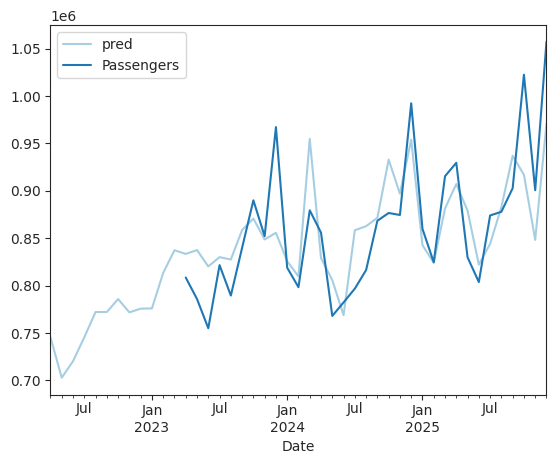

In [154]:
predictions['pred'].plot(legend = True)
df_test_xg2['Passengers'].plot(legend = True)

## **RESULTS**

In [155]:
#Naive
naive_rmse=sqrt(mean_squared_error(naive_train['Passengers_t-1'],naive_train['Passengers']))
naive_r2_score = r2_score(naive_train['Passengers'], naive_train['Passengers_t-1'])
naive_mae = mean_absolute_error(naive_train['Passengers_t-1'], naive_train['Passengers'])

y_true_filtered = y_true_arr[mask]
y_pred_filtered = y_pred_arr[mask]
#MAPE on the filtered data
naive_mape = mean_absolute_percentage_error(y_true_filtered, y_pred_filtered)

#SARIMA
sarima_rmse = sqrt(mean_squared_error(X_sarima_test.Passengers, np.array(predict_sarima1)))
sarima_mape = mean_absolute_percentage_error(X_sarima_test.Passengers,np.array(predict_sarima1))
sarima_mae = mean_absolute_error(X_sarima_test.Passengers, np.array(predict_sarima1))
sarima_r2_score = r2_score(X_sarima_test.Passengers,  np.array(predict_sarima1))

#SARIMAX
rmse_exog = sqrt(mean_squared_error(X_exog_test['Passengers'], np.array(prediction_exog)))
mpe_exog = mean_absolute_percentage_error(np.array(prediction_exog), X_exog_test['Passengers'])
r2_score_exog = r2_score(np.array(prediction_exog), X_exog_test['Passengers'])
mae_exog = mean_absolute_error(X_exog_test['Passengers'], np.array(prediction_exog))

#XGBOOST
xg_rmse = metric.values[0][1]
xg_mape = metric.values[0][0]
xg_mae = metric.values[0][-2]
xg_r2score = metric.values[0][-1]


In [156]:
all_metrics = [
    { 'MODEL': 'Naive Bayes', 'RMSE': naive_rmse, 'MAPE': naive_mape, 'MAE': naive_mae, 'r2_score': naive_r2_score },
    { 'MODEL': 'SARIMA', 'RMSE': sarima_rmse, 'MAPE': sarima_mape, 'MAE' : sarima_mae ,'r2_score': sarima_r2_score },
    { 'MODEL': 'SARIMAX', 'RMSE': rmse_exog, 'MAPE': mpe_exog, 'MAE' : mae_exog ,'r2_score': r2_score_exog },
    { 'MODEL': 'XGBOOST', 'RMSE': xg_rmse, 'MAPE': xg_mape, 'MAE' : xg_mae ,'r2_score': xg_r2score },
    ]

# Display as DataFrame
df_metrics = pd.DataFrame(all_metrics)
df_metrics

,MODEL,RMSE,MAPE,MAE,r2_score
0,Naive Bayes,98307.923729,0.111449,67003.492424,0.785624
1,SARIMA,47427.036760,0.043970,38247.899249,0.556415
2,SARIMAX,208722.036607,0.294517,189544.419280,-6.250898
3,XGBOOST,47123.475131,0.044819,37217.618056,0.690068


In [157]:
df.head()

,Passengers,tourists,cpi,Trade_balance,crude_oil,unemployment_rate,covid_flag,gdp_per_capta,month,year,month_name
Date,,,,,,,,,,,
2012-04-01,819885,802834.0,6.1,-9900000000,890.44,24.84194,0,8076.985243,4,2012,Apr
2012-05-01,765773,692046.0,5.7,-8900000000,846.60,24.84194,0,7992.946301,5,2012,May
2012-06-01,745731,653686.0,5.5,-5700000000,761.13,24.84194,0,7909.217413,6,2012,Jun
2012-07-01,794131,793245.0,4.9,-6700000000,798.05,25.06654,0,7825.796867,7,2012,Jul
2012-08-01,791901,77562.0,5.0,-12200000000,871.23,25.06654,0,7742.682963,8,2012,Aug


In [158]:
df.to_csv('FAOR_forecast.csv')